# GARCH in stocks

We know that stocks have volatility clustering, which means that periods of high volatility tend to be followed by more periods of high volatility, and periods of low volatility tend to be followed by more periods of low volatility.

GARCH (Generalized Autoregressive Conditional Heteroskedasticity) models are a class of statistical models that are used to model and forecast the volatility of financial time series data, such as stock prices. GARCH models are particularly useful for capturing the volatility clustering observed in financial markets.

GARCH has the format
$$\sigma_t^2 = \omega + \alpha \epsilon_{t-1}^2 + \beta \sigma_{t-1}^2$$

Where:  
- $\sigma_t^2$ is the conditional variance (volatility) at time $t$.
- $\omega$ is a constant term.
- $\alpha$ is the coefficient for the lagged squared error term ($\epsilon_{t-1}^2$), which captures the impact of past shocks on current volatility.
- $\beta$ is the coefficient for the lagged conditional variance term ($\sigma_{t   -1}^2$), which captures the persistence of volatility over time.


## Understanding the GARCH model
GARCH model is defined as follows:
$$r_t = \mu + \sigma_t \epsilon_t$$
$$\sigma_t^2 = \omega + \alpha r_{t-1}^2 + \beta \sigma_{t-1}^2$$

Where:
- $r_t$ is the return at time $t$.
- $\mu$ is the mean return.
- $\sigma_t$ is the conditional standard deviation (volatility) at time $t$.
- $\epsilon_t$ is a white noise error term with mean zero and variance one.

The GARCH model captures the volatility clustering in financial time series data by allowing the conditional variance to depend on past squared errors and past variances. The parameters $\alpha$ and $\beta$ determine how much past shocks and past volatility influence current volatility.

The problem is that the daily return is almost zero. So, this equation is then simplified to:
$$\sigma_t^2 = \omega + \alpha r_{t-1}^2 + \beta \sigma_{t-1}^2$$

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np  
from arch import arch_model

In [3]:
spy = yf.download('SPY', start='2000-01-01', end='2024-06-30')
spy['Returns'] = spy['Close'].pct_change().dropna() * 100  # Convert to percentage returns

# Fit GARCH(1,1) model  
model = arch_model(spy['Returns'].dropna(), vol='Garch', p=1, q=1, dist='normal')
res = model.fit(disp='off')
print(res.summary())

[*********************100%***********************]  1 of 1 completed

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                Returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -8467.80
Distribution:                  Normal   AIC:                           16943.6
Method:            Maximum Likelihood   BIC:                           16970.5
                                        No. Observations:                 6160
Date:                Fri, Feb 20 2026   Df Residuals:                     6159
Time:                        19:56:55   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0739  1.024e-02      7.211  5.547e-13 [5.

1. One might assume that $R^2 = 0$ means bad fit for this model, but it is not the case. The GARCH model is designed to capture the volatility of returns, not the returns themselves. Therefore, the $R^2$ value may not be a meaningful measure of the model's performance in this context.
2. Here, we observe that the $\alpha$ and $\beta$ parameters are both positive, which indicates that past shocks and past volatility have a significant impact on current volatility. We can also observe that $\alpha + \beta < 1$, which is a necessary condition for the GARCH model to be stationary and mean-reverting. This ensures that the volatility process does not explode over time and remains stable.
3. We also see that $\alpha + \beta \approx 0.95$, which suggests that the volatility is highly persistent, meaning that shocks to volatility tend to have a long-lasting effect.
4. We also see that $\omega$ is a small positive value, which indicates that there is a baseline level of volatility even in the absence of shocks.
5. To look for models with better fit, we can try different specifications of the GARCH model, such as GARCH(2,1) or GARCH(1,2), which include additional lagged terms but from the famous 2005 academic paper `Does anything beat a GARCH(1,1)?` by Peter R. Hansen and Asger Lunde, it is found that GARCH(1,1) is often sufficient for modeling financial time series data, and more complex models may not necessarily provide a better fit. Therefore, it is important to balance model complexity with interpretability and parsimony when selecting a GARCH model for financial data analysis.

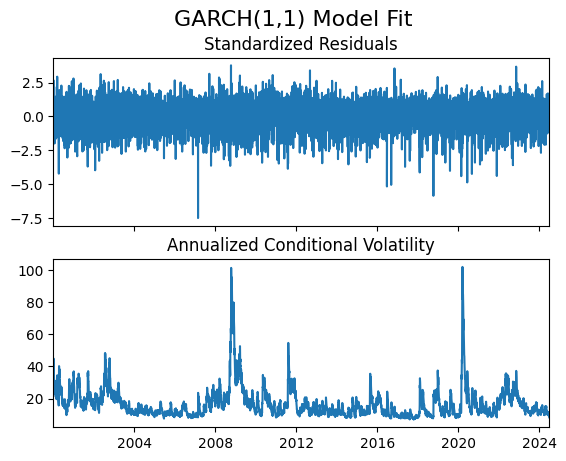

In [4]:
fig = res.plot(annualize='D')
plt.suptitle('GARCH(1,1) Model Fit', fontsize=16)
plt.show()

# Volatility Half-Life

The volatility half-life is a measure of how quickly the volatility of a financial time series decays over time. It is defined as the time it takes for the volatility to decrease by half from its initial value. In the context of a GARCH(1,1) model, the volatility half-life can be calculated using the parameters $\alpha$ and $\beta$ as follows:
$$\text{Half-Life} = \frac{\ln(0.5)}{\ln(\alpha + \beta)}$$

Where:
- $\alpha$ is the coefficient for the lagged squared error term in the GARCH(1,1) model.
- $\beta$ is the coefficient for the lagged conditional variance term in the GARCH(1,1) model.

## Proof: 
To derive the formula for the volatility half-life in a GARCH(1,1) model, we start with the conditional variance equation:
$$\sigma_t^2 = \omega + \alpha r_{t-1}^2 + \beta \sigma_{t-1}^2$$
Assuming that the process is stationary, we can take the expectation of both sides $(E_t$, the expectation where we know information until time $t)$ to find the unconditional variance:
$$E_t[\sigma_{t + 1}^2] = \omega + \alpha E_t[r_t^2] + \beta E_t[\sigma_t^2]$$
Since $E_t[r_t^2] = E_t[\sigma_{t}^2\epsilon_{t}^2] = \sigma_{t}^2E_t[\epsilon_{t}^2] = \sigma_{t}^2$, $(\sigma_{t}$ becomes a constant since we know information until time $t)$ for a GARCH(1,1) model, we can simplify the equation to:
$$E_t[\sigma_{t + 1}^2] = \omega + (\alpha + \beta) \sigma_t^2$$

Now, for $E_t[\sigma_{t + 1}^2\epsilon_{t+1}^2]$, as $\sigma_{t + 1}$ and $\epsilon_{t+1}$ are independent, we can write:
$$E_t[\sigma_{t + 1}^2\epsilon_{t+1}^2] = E_t[\sigma_{t + 1}^2]E_t[\epsilon_{t+1}^2] = E_t[\sigma_{t + 1}^2]$$
By the way, we can also calculate tomorrow's variance using time $t$ information. So, $\sigma_{t+1}^2 = \omega + \alpha r_t^2 + \beta \sigma_t^2$ is a constant.

So, 
$$E_t[\sigma_{t + 1}^2] = \omega + (\alpha + \beta) \sigma_t^2$$
This shows that the expected value of the conditional variance at time $t+1$ is a linear function of the conditional variance at time $t$. This relationship is key to deriving the half-life formula.
To find the half-life, we want to determine the time it takes for the volatility to decrease by half. We can express the conditional variance at time $t+n$ as:
$$E_t[\sigma_{t + n}^2] = \omega + (\alpha + \beta) E_t[\sigma_{t + n - 1}^2]$$
By iterating this process, we can express the conditional variance at time $t+n$ in terms of the initial variance at time $t$:
$$E_t[\sigma_{t + n}^2] = \omega \sum_{i=0}^{n-1} (\alpha + \beta)^i + (\alpha + \beta)^n \sigma_t^2$$
As $n$ approaches infinity, the first term converges to $\frac{\omega}{1 - (\alpha + \beta)}$, which is the long-term variance. The second term decays exponentially at a rate determined by $\alpha + \beta$. To find the half-life, we set the second term equal to half of the initial variance:
$$\frac{1}{2} \sigma_t^2 = (\alpha + \beta)^n \sigma_t^2$$
Dividing both sides by $\sigma_t^2$, we get:
$$\frac{1}{2} = (\alpha + \beta)^n$$
Taking the natural logarithm of both sides, we have:
$$\ln\left(\frac{1}{2}\right) = n \ln(\alpha + \beta)$$
Finally, solving for $n$ gives us the formula for the volatility half-life:
$$\text{Half-Life} = \frac{\ln(0.5)}{\ln(\alpha + \beta)}$$
This formula indicates that the half-life of volatility shocks in a GARCH(1,1) model is determined by the sum of the parameters $\alpha$ and $\beta$. A higher value of $\alpha + \beta$ implies a longer half-life, meaning that volatility shocks will persist for a longer period of time. Conversely, a lower value of $\alpha + \beta$ implies a shorter half-life, indicating that volatility shocks will decay more quickly.

In [5]:
time_for_half_life = -np.log(2) / np.log(res.params['alpha[1]'] + res.params['beta[1]'])
print(f"Half-life of volatility shocks: {time_for_half_life:.2f} days")

Half-life of volatility shocks: 40.66 days
